In [6]:
!pip install biopython

In [7]:
!pip install gudhi

In [8]:
"""
=============================================================================
preprocessing.py — Pipeline tiền xử lý dữ liệu Protein cho phân tích TDA
=============================================================================
Mô tả:
    Tải cấu trúc protein từ RCSB PDB, trích xuất tọa độ Carbon Alpha (CA),
    chuẩn hoá Z-score phục vụ phân tích Topological Data Analysis (TDA).

"""

import os
import warnings
import urllib.request
from typing import Optional
import pandas as pd
import numpy as np
from Bio.PDB import PDBParser
import gudhi as gd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ============================================================================
# Định nghĩa nhóm protein cần phân loại
# ============================================================================
PROTEIN_GROUPS: dict[str, list[str]] = {
    "alpha_helix": ["1ake", "2rhe", "1gcn"],   # Cấu trúc xoắn alpha
    "beta_sheet":  ["1cd8", "2pka", "1qqt"],    # Cấu trúc phiến gấp beta
    "mixed":       ["1tim", "3tnd", "4hhb"],    # Cấu trúc hỗn hợp
}

# URL gốc của RCSB PDB dùng để tải file .pdb
RCSB_BASE_URL = "https://files.rcsb.org/download"


class ProteinPreprocessor:
    """
    Lớp chịu trách nhiệm toàn bộ pipeline tiền xử lý protein:
        1. Tải file PDB từ internet (nếu chưa có trên máy).
        2. Phân tích file PDB, trích xuất tọa độ nguyên tử Carbon Alpha (CA).
        3. Chuẩn hoá đám mây điểm (point cloud) theo Z-score.
        4. Đóng gói kết quả và lưu ra file .npy.
    """

    def __init__(self, data_dir: str = "protein_data", output_file: str = "protein_dataset_clean.npy"):
        """
        Khởi tạo bộ tiền xử lý.

        Args:
            data_dir:    Thư mục lưu trữ file .pdb (tạo tự động nếu chưa tồn tại).
            output_file: Tên file .npy đầu ra chứa dataset đã làm sạch.
        """
        self.data_dir = data_dir
        self.output_file = output_file

        # Bộ parser PDB của Biopython
        self.parser = PDBParser(QUIET=True)

        # Tạo thư mục lưu trữ nếu chưa tồn tại
        os.makedirs(self.data_dir, exist_ok=True)

    # -----------------------------------------------------------------------
    # Bước 1: Tải file PDB
    # -----------------------------------------------------------------------
    def download_pdb(self, pdb_id: str) -> Optional[str]:
        """
        Tải file .pdb từ RCSB nếu chưa có trong thư mục cục bộ.


        """
        # Chuẩn hoá mã PDB về chữ thường (RCSB chấp nhận cả hai)
        pdb_id_lower = pdb_id.lower()
        file_name = f"{pdb_id_lower}.pdb"
        file_path = os.path.join(self.data_dir, file_name)

        # Nếu file đã tồn tại → không cần tải lại
        if os.path.exists(file_path):
            print(f"  [OK] File da ton tai: {file_name}")
            return file_path

        # Xây dựng URL tải — RCSB dùng mã viết HOA trong đường dẫn
        url = f"{RCSB_BASE_URL}/{pdb_id.upper()}.pdb"
        print(f"  [>>] Dang tai {pdb_id.upper()}.pdb tu RCSB PDB ...")

        try:
            urllib.request.urlretrieve(url, file_path)
            print(f"  [OK] Tai thanh cong -> {file_path}")
            return file_path
        except Exception as e:
            # Bắt mọi lỗi mạng / HTTP, in cảnh báo thay vì crash
            warnings.warn(f"  [FAIL] Khong the tai {pdb_id}: {e}")
            return None

    # -----------------------------------------------------------------------
    # Bước 2: Trích xuất tọa độ Carbon Alpha (CA)
    # -----------------------------------------------------------------------
    def extract_ca_coords(self, file_path: str, pdb_id: str) -> Optional[np.ndarray]:
        """
        Đọc file PDB và trích xuất tọa độ 3D của các nguyên tử Carbon Alpha.


            - Carbon Alpha (CA hay Cα) là nguyên tử carbon trung tâm trong mỗi
              amino acid. Nó nằm giữa nhóm amino (-NH₂) và nhóm carboxyl (-COOH).
            - Tập hợp tọa độ CA tạo thành "xương sống" (backbone) của protein,
              đại diện cho hình dáng tổng thể mà không cần toàn bộ nguyên tử.
            - Đây là biểu diễn thô (coarse-grained) phổ biến trong phân tích
              cấu trúc protein và TDA.

        Args:
            file_path: Đường dẫn tới file .pdb.
            pdb_id:    Mã PDB (dùng để ghi log).

        Returns:
            Mảng numpy kích thước (N, 3) chứa tọa độ CA, hoặc None nếu lỗi.
        """
        try:
            # Phân tích (parse) file PDB bằng Biopython
            structure = self.parser.get_structure(pdb_id, file_path)
        except Exception as e:
            warnings.warn(f"  [FAIL] Loi phan tich file {pdb_id}: {e}")
            return None

        ca_coords = []

        # Duyệt qua toàn bộ cây phân cấp: Structure → Model → Chain → Residue → Atom
        # Chỉ lấy nguyên tử có tên 'CA' (Carbon Alpha)
        for model in structure:
            for chain in model:
                for residue in chain:
                    # Bỏ qua các hetero-residue (nước, ligand, ion, ...)
                    # Residue "chuẩn" (amino acid) có hetflag là khoảng trắng ' '
                    if residue.get_id()[0] != " ":
                        continue

                    if "CA" in residue:
                        atom = residue["CA"]
                        # get_vector() trả về Vector 3D → chuyển sang numpy array
                        ca_coords.append(atom.get_vector().get_array())

        # Kiểm tra: nếu không tìm thấy bất kỳ CA nào → cảnh báo
        if len(ca_coords) == 0:
            warnings.warn(f"  [FAIL] Khong tim thay nguyen tu CA trong {pdb_id}")
            return None

        # Chuyển danh sách toạ độ thành mảng numpy (N, 3)
        point_cloud = np.array(ca_coords, dtype=np.float64)
        print(f"  [OK] Trich xuat {point_cloud.shape[0]} nguyen tu CA tu {pdb_id}")
        return point_cloud

    # -----------------------------------------------------------------------
    # Bước 3: Chuẩn hoá Z-score
    # -----------------------------------------------------------------------
    @staticmethod
    def normalize_zscore(point_cloud: np.ndarray) -> np.ndarray:
        """
        Chuẩn hoá đám mây điểm theo phương pháp Z-score trên từng trục toạ độ.

        Công thức toán học:
            z_i = (x_i - μ) / σ

        Trong đó:
            - x_i : giá trị toạ độ gốc của điểm thứ i trên một trục (x, y, hoặc z)
            - μ   : giá trị trung bình (mean) của tất cả các điểm trên trục đó
            - σ   : độ lệch chuẩn (standard deviation) trên trục đó
            - z_i : giá trị đã chuẩn hoá

        Mục đích:
            - Đưa đám mây điểm về tâm gốc toạ độ (mean = 0).
            - Co/giãn để mỗi trục có phương sai đơn vị (std = 1).
            - Loại bỏ ảnh hưởng của vị trí và tỉ lệ → giữ lại hình dáng tô pô.

        Xử lý đặc biệt:
            - Nếu σ = 0 trên một trục (tất cả điểm có cùng toạ độ trên trục đó),
              phép chia sẽ cho ra inf/nan. Khi đó ta đặt σ = 1 để tránh lỗi,
              kết quả trên trục đó chỉ đơn giản bằng (x - μ) = 0.

        Args:
            point_cloud: Mảng numpy (N, 3) — toạ độ 3D chưa chuẩn hoá.

        Returns:
            Mảng numpy (N, 3) — toạ độ 3D đã chuẩn hoá Z-score.
        """
        # Tính trung bình theo từng cột (trục x, y, z) → vector (3,)
        mean = np.mean(point_cloud, axis=0)

        # Tính độ lệch chuẩn theo từng cột → vector (3,)
        std = np.std(point_cloud, axis=0)

        # Xử lý trường hợp đặc biệt: σ = 0 → thay bằng 1 để tránh chia cho 0
        # np.where giữ giá trị gốc nếu std > 0, thay bằng 1.0 nếu std == 0
        std_safe = np.where(std == 0, 1.0, std)

        # Áp dụng công thức Z-score: z = (x - μ) / σ
        normalized = (point_cloud - mean) / std_safe

        return normalized

    # -----------------------------------------------------------------------
    # Bước 4: Chạy toàn bộ pipeline
    # -----------------------------------------------------------------------
    def run(self, protein_groups: dict[str, list[str]]) -> list[dict]:
        """
        Thực thi pipeline tiền xử lý hoàn chỉnh cho tất cả các protein.

        Quy trình cho mỗi PDB ID:
            1. Tải file .pdb (nếu cần)
            2. Trích xuất tọa độ CA
            3. Chuẩn hoá Z-score
            4. Đóng gói thành dictionary

        Args:
            protein_groups: Dict ánh xạ nhãn phân loại → danh sách mã PDB.
                            Ví dụ: {"alpha_helix": ["1ake", "2rhe", ...], ...}

        Returns:
            Danh sách các dictionary, mỗi phần tử có dạng:
            {
                "pdb_id": str,
                "label": str,
                "point_cloud": np.ndarray shape (N, 3)
            }
        """
        dataset = []

        for label, pdb_ids in protein_groups.items():
            print(f"\n{'='*60}")
            print(f"  Nhom: {label.upper()} - {len(pdb_ids)} protein")
            print(f"{'='*60}")

            for pdb_id in pdb_ids:
                print(f"\n  --- Xu ly: {pdb_id.upper()} ---")

                # B1: Tải file PDB
                file_path = self.download_pdb(pdb_id)
                if file_path is None:
                    print(f"  [!] Bo qua {pdb_id} (khong tai duoc file)")
                    continue

                # B2: Trích xuất tọa độ Carbon Alpha
                point_cloud = self.extract_ca_coords(file_path, pdb_id)
                if point_cloud is None:
                    print(f"  [!] Bo qua {pdb_id} (khong trich xuat duoc CA)")
                    continue

                # B3: Chuẩn hoá Z-score
                point_cloud_normalized = self.normalize_zscore(point_cloud)

                # B4: Đóng gói kết quả
                record = {
                    "pdb_id": pdb_id,
                    "label": label,
                    "point_cloud": point_cloud_normalized,
                }
                dataset.append(record)
                print(f"  [OK] Hoan tat {pdb_id} -> point_cloud shape: {point_cloud_normalized.shape}")

        return dataset

    # -----------------------------------------------------------------------
    # Bước 5: Lưu dataset ra file .npy
    # -----------------------------------------------------------------------
    def save(self, dataset: list[dict]) -> None:
        """
        Lưu dataset dưới dạng file .npy (numpy binary format).

        Lưu ý:
            - numpy.save với allow_pickle=True cho phép lưu danh sách chứa
              các dictionary có giá trị là numpy array.
            - Khi load lại cần: np.load(file, allow_pickle=True)

        Args:
            dataset: Danh sách dictionary, mỗi phần tử chứa pdb_id, label,
                     và point_cloud (đã chuẩn hoá).
        """
        np.save(self.output_file, np.array(dataset, dtype=object), allow_pickle=True)
        print(f"\n{'='*60}")
        print(f"  [*] Dataset da luu -> {self.output_file}")
        print(f"  [*] Tong so protein hop le: {len(dataset)}")
        print(f"{'='*60}")


# ============================================================================
# MAIN — Điểm khởi chạy chương trình
# ============================================================================
def main():
    """
    Hàm main điều phối toàn bộ pipeline:
        1. Khởi tạo ProteinPreprocessor
        2. Chạy pipeline trên tất cả các nhóm protein
        3. In tóm tắt thống kê
        4. Lưu kết quả ra file .npy
    """
    print("=" * 60)
    print("   PIPELINE TIEN XU LY DU LIEU PROTEIN CHO TDA")
    print("=" * 60)

    # Khoi tao bo tien xu ly
    preprocessor = ProteinPreprocessor(
        data_dir="protein_data",
        output_file="protein_dataset_clean.npy",
    )

    # Chạy pipeline
    dataset = preprocessor.run(PROTEIN_GROUPS)

    # In bảng tóm tắt kết quả
    print(f"\n{'='*60}")
    print("  BANG TOM TAT KET QUA")
    print(f"{'='*60}")
    print(f"  {'PDB ID':<10} {'Nhan':<15} {'So CA':<10} {'Shape'}")
    print(f"  {'-'*50}")
    for record in dataset:
        shape = record["point_cloud"].shape
        print(f"  {record['pdb_id'].upper():<10} {record['label']:<15} {shape[0]:<10} {shape}")

    # Luu ket qua
    preprocessor.save(dataset)

    return dataset


if __name__ == "__main__":
    main()


   PIPELINE TIEN XU LY DU LIEU PROTEIN CHO TDA

  Nhom: ALPHA_HELIX - 3 protein

  --- Xu ly: 1AKE ---
  [OK] File da ton tai: 1ake.pdb
  [OK] Trich xuat 428 nguyen tu CA tu 1ake
  [OK] Hoan tat 1ake -> point_cloud shape: (428, 3)

  --- Xu ly: 2RHE ---
  [OK] File da ton tai: 2rhe.pdb
  [OK] Trich xuat 114 nguyen tu CA tu 2rhe
  [OK] Hoan tat 2rhe -> point_cloud shape: (114, 3)

  --- Xu ly: 1GCN ---
  [OK] File da ton tai: 1gcn.pdb
  [OK] Trich xuat 29 nguyen tu CA tu 1gcn
  [OK] Hoan tat 1gcn -> point_cloud shape: (29, 3)

  Nhom: BETA_SHEET - 3 protein

  --- Xu ly: 1CD8 ---
  [OK] File da ton tai: 1cd8.pdb
  [OK] Trich xuat 114 nguyen tu CA tu 1cd8
  [OK] Hoan tat 1cd8 -> point_cloud shape: (114, 3)

  --- Xu ly: 2PKA ---
  [OK] File da ton tai: 2pka.pdb
  [OK] Trich xuat 464 nguyen tu CA tu 2pka
  [OK] Hoan tat 2pka -> point_cloud shape: (464, 3)

  --- Xu ly: 1QQT ---
  [OK] File da ton tai: 1qqt.pdb
  [OK] Trich xuat 546 nguyen tu CA tu 1qqt
  [OK] Hoan tat 1qqt -> point_cloud 

In [9]:
dataset = np.load("protein_dataset_clean.npy", allow_pickle=True)
record = next(item for item in dataset if item["pdb_id"].lower() == "1ake")
points = record["point_cloud"]

<Figure size 700x700 with 0 Axes>

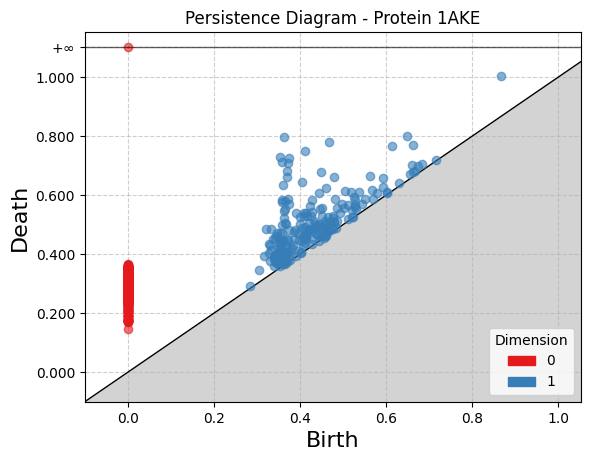

In [7]:
def plot_h1_persistence_diagram(points, pdb_id):
    """
    Chỉ tính toán và hiển thị Persistence Diagram cho Protein.
    """
    # 1. Xây dựng Rips Complex (max_dimension=2 là đủ để thấy vòng H1)
    rips = gd.RipsComplex(points=points, max_edge_length=2.0)
    st = rips.create_simplex_tree(max_dimension=2)

    # 2. Tính toán Persistence
    persistence = st.persistence()

    # 3. Vẽ biểu đồ Diagram
    # Lưu ý: H0 (điểm) thường màu đỏ, H1 (vòng) thường màu xanh dương/lá tùy version
    plt.figure(figsize=(7, 7))
    gd.plot_persistence_diagram(persistence, legend=True)
    plt.title(f"Persistence Diagram - Protein {pdb_id.upper()}")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# --- Chạy thử ---
plot_h1_persistence_diagram(points, record["pdb_id"])

Đang xử lý biểu đồ cho: 1AKE


<Figure size 700x700 with 0 Axes>

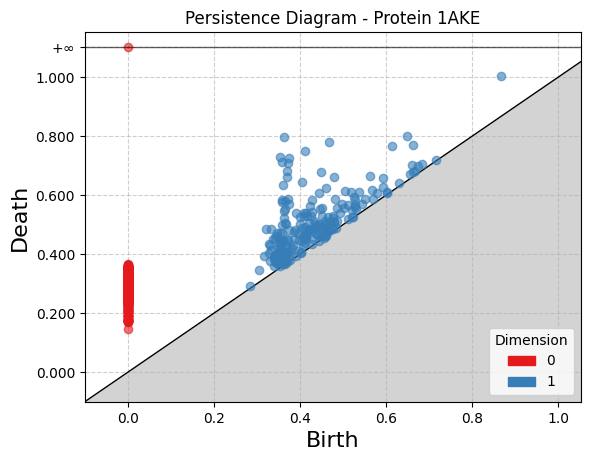

Đang xử lý biểu đồ cho: 2RHE


<Figure size 700x700 with 0 Axes>

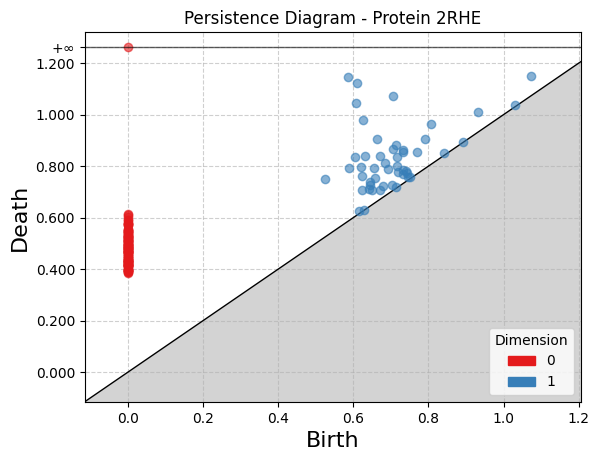

Đang xử lý biểu đồ cho: 1GCN


<Figure size 700x700 with 0 Axes>

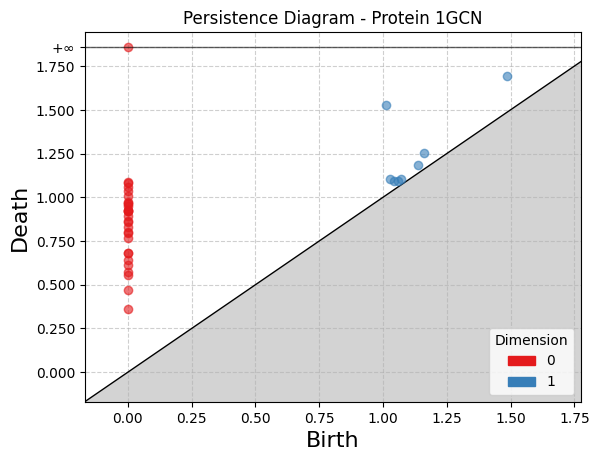

Đang xử lý biểu đồ cho: 1CD8


<Figure size 700x700 with 0 Axes>

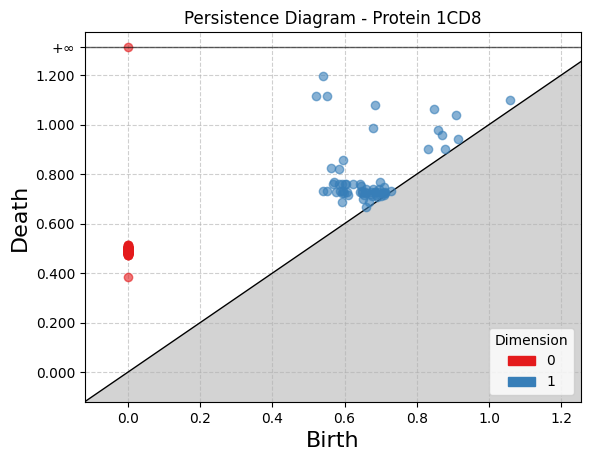

Đang xử lý biểu đồ cho: 2PKA


<Figure size 700x700 with 0 Axes>

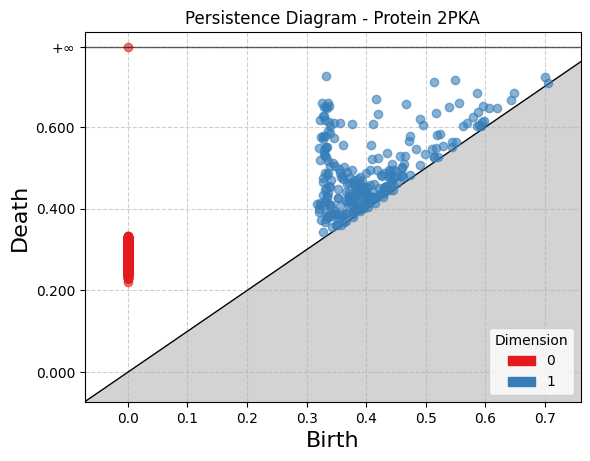

Đang xử lý biểu đồ cho: 1QQT


<Figure size 700x700 with 0 Axes>

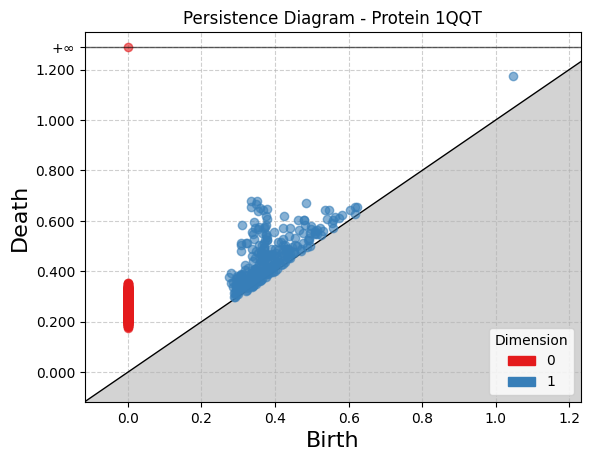

Đang xử lý biểu đồ cho: 1TIM


<Figure size 700x700 with 0 Axes>

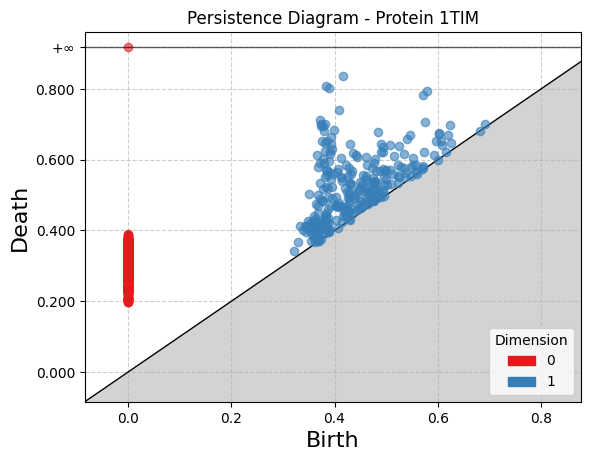

Đang xử lý biểu đồ cho: 3TND


<Figure size 700x700 with 0 Axes>

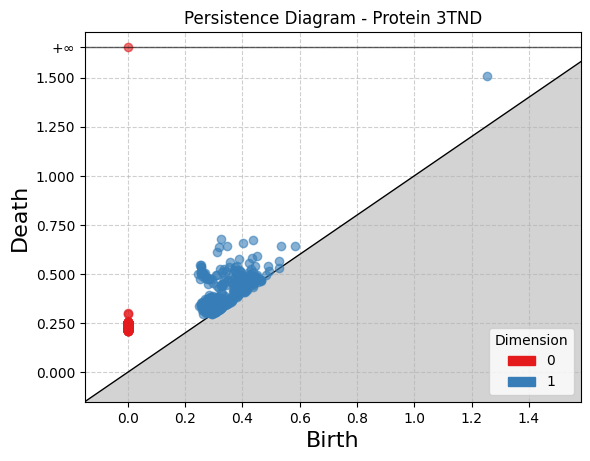

Đang xử lý biểu đồ cho: 4HHB


<Figure size 700x700 with 0 Axes>

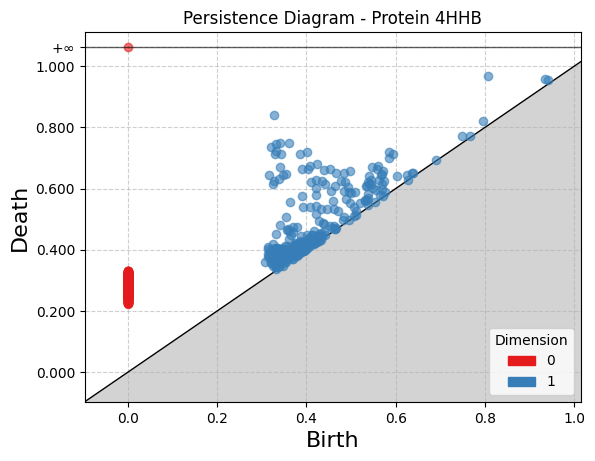

In [9]:
# Danh sách các PDB ID cần chạy
list_ids = ['1ake', '2rhe', '1gcn', '1cd8', '2pka', '1qqt', '1tim', '3tnd', '4hhb']

for pid in list_ids:
    # 1. Tìm bản ghi (record) tương ứng trong dataset
    try:
        record = next(item for item in dataset if item["pdb_id"].lower() == pid.lower())
        points = record["point_cloud"]

        # 2. Gọi hàm vẽ đã định nghĩa ở trên
        print(f"Đang xử lý biểu đồ cho: {pid.upper()}")
        plot_h1_persistence_diagram(points, pid)

    except StopIteration:
        print(f"Lỗi: Không tìm thấy dữ liệu cho {pid} trong dataset của bạn.")

In [10]:
import pandas as pd
import numpy as np
import gudhi as gd

def get_h1_persistence_stats(points, pid, threshold=0.4):
    """
    Trích xuất các thông số liên quan đến cấu trúc vòng (H1).
    """
    # 1. Xây dựng phức hợp Rips
    rips = gd.RipsComplex(points=points, max_edge_length=2.0)
    st = rips.create_simplex_tree(max_dimension=2)
    st.persistence()

    # 2. Lấy các khoảng sống của H1
    h1 = st.persistence_intervals_in_dimension(1)

    # Nếu không có vòng nào được tìm thấy
    if len(h1) == 0:
        return {
            "PDB_ID": pid.upper(),
            "Số vòng H1 (Stable)": 0,
            "Max Death": 0,
            "Max Persistence": 0
        }

    # 3. Tính độ bền
    persistence_values = h1[:, 1] - h1[:, 0]
    stable_h1 = persistence_values[persistence_values > threshold]

    return {
        "PDB_ID": pid.upper(),
        "Số vòng H1 (Stable)": len(stable_h1),
        "Max Death": round(float(np.max(h1[:, 1])), 2),
        "Max Persistence": round(float(np.max(persistence_values)), 2)
    }

# --- CHẠY KIỂM TRA VÀ TỔNG HỢP ---
all_h1_stats = []

# Đảm bảo dataset đã được load trước đó
# dataset = np.load("protein_dataset_clean.npy", allow_pickle=True)

for record in dataset:
    pid = record["pdb_id"]
    points = record["point_cloud"]

    # Tính toán và thêm vào danh sách
    stats = get_h1_persistence_stats(points, pid)
    all_h1_stats.append(stats)

# Chuyển thành DataFrame
df_h1_summary = pd.DataFrame(all_h1_stats)

# Sắp xếp theo ID để dễ nhìn
df_h1_summary = df_h1_summary.sort_values("PDB_ID")

print("\nBẢNG THỐNG KÊ CẤU TRÚC VÒNG (H1) - Ngưỡng bền vững > 0.4:")
print(df_h1_summary.to_string(index=False))


BẢNG THỐNG KÊ CẤU TRÚC VÒNG (H1) - Ngưỡng bền vững > 0.4:
PDB_ID  Số vòng H1 (Stable)  Max Death  Max Persistence
  1AKE                    1       1.00             0.43
  1CD8                    3       1.19             0.65
  1GCN                    1       1.69             0.52
  1QQT                    0       1.17             0.35
  1TIM                    3       0.83             0.42
  2PKA                    0       0.72             0.39
  2RHE                    3       1.15             0.56
  3TND                    0       1.51             0.35
  4HHB                    4       0.97             0.51


<>:52: SyntaxWarning: invalid escape sequence '\e'
<>:52: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_819/2388825297.py:52: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title(f"$\epsilon = {eps}$\nEdges: {len(edges)} | Faces: {len(faces)}")


--- Đang phân tích đa chiều cho Protein 1AKE ---
  [+] Epsilon 0.50: 1434 cạnh, 1449 mặt tam giác.
  [+] Epsilon 0.90: 6018 cạnh, 32603 mặt tam giác.
  [+] Epsilon 1.20: 12207 cạnh, 146972 mặt tam giác.
  [+] Epsilon 1.50: 20019 cạnh, 421731 mặt tam giác.


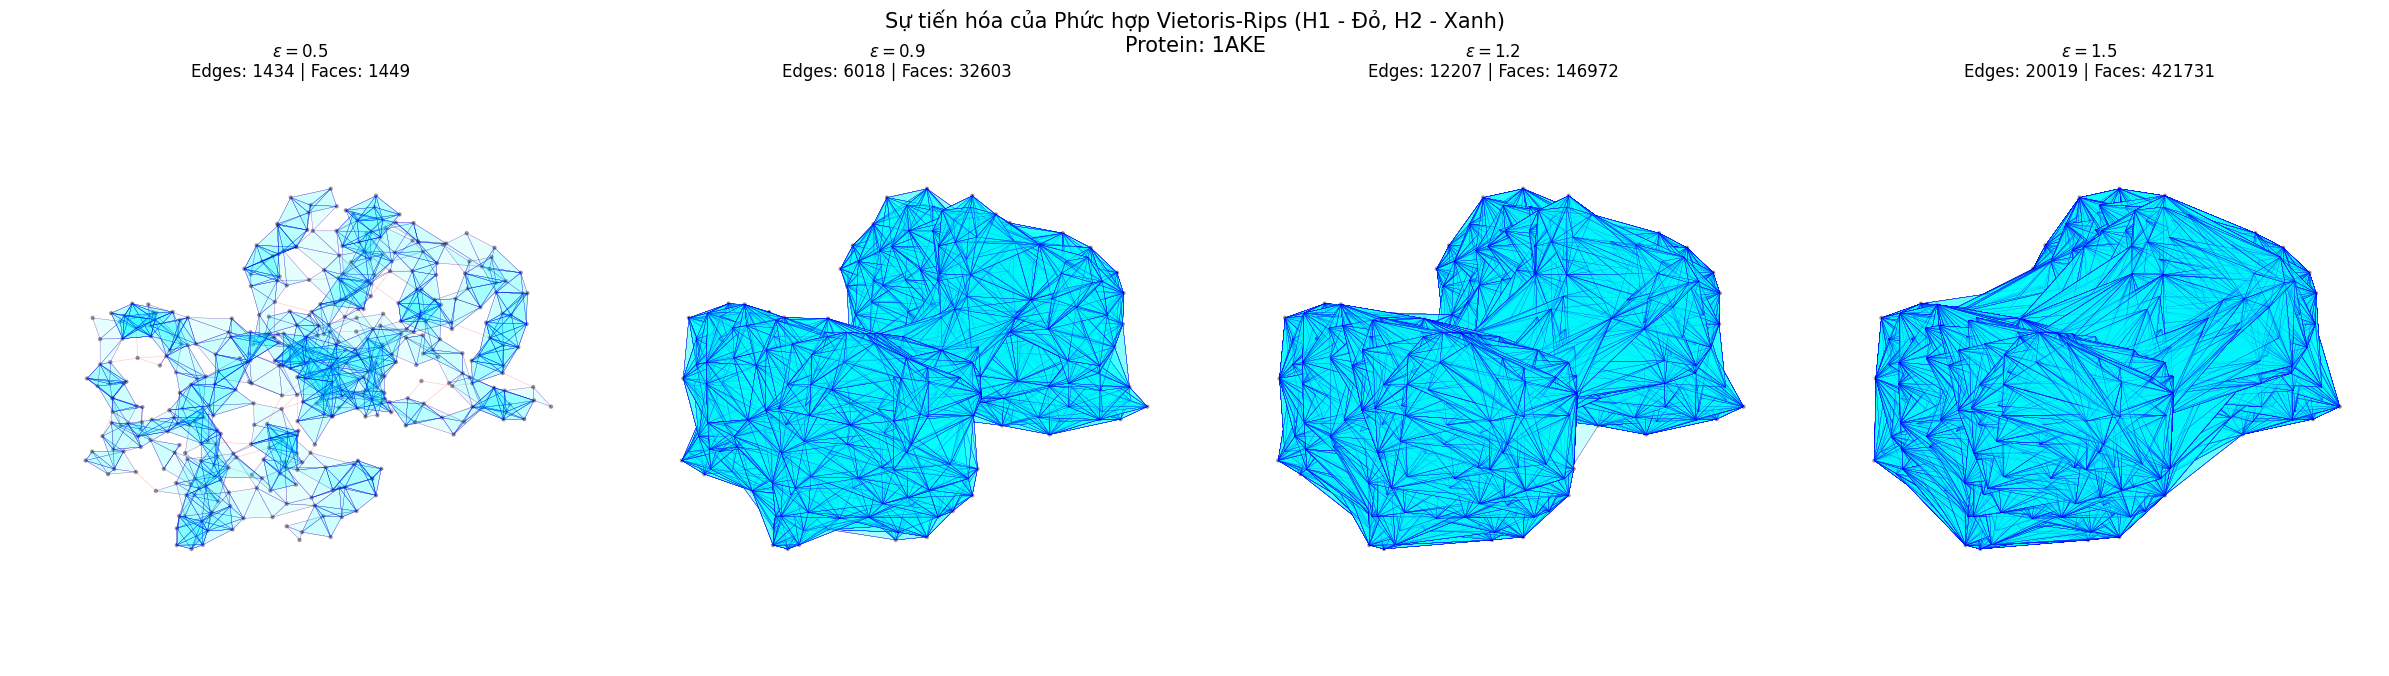

In [ ]:
# 1. Load dữ liệu đã chuẩn hóa của bạn
dataset = np.load("protein_dataset_clean.npy", allow_pickle=True)
record = next(item for item in dataset if item["pdb_id"].lower() == "1ake")
points = record["point_cloud"]

def plot_multidim_filtration(points, epsilon_list):
    n_steps = len(epsilon_list)
    fig = plt.figure(figsize=(6 * n_steps, 7))

    print(f"--- Đang phân tích đa chiều cho Protein {record['pdb_id'].upper()} ---")

    for i, eps in enumerate(epsilon_list):
        ax = fig.add_subplot(1, n_steps, i + 1, projection='3d')

        # Bước 1: Xây dựng Simplex Tree cho ngưỡng eps hiện tại
        rips = gd.RipsComplex(points=points, max_edge_length=eps)
        st = rips.create_simplex_tree(max_dimension=4)

        # Bước 2: Lấy danh sách các simplices
        simplices = list(st.get_skeleton(3))

        # Vẽ các điểm (H0)
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], c='black', s=5, alpha=0.3)

        edges = []
        faces = []

        for simplex, filtration in simplices:
            if len(simplex) == 2: # Cạnh (Edges - H1)
                edges.append(points[list(simplex)])
            elif len(simplex) == 3: # Mặt (Faces - H2)
                faces.append(points[list(simplex)])

        # Vẽ các cạnh (H1) - Màu đỏ
        for edge in edges:
            ax.plot(edge[:, 0], edge[:, 1], edge[:, 2], c='red', alpha=0.2, linewidth=0.5)

        # Vẽ các mặt tam giác (H2) - Màu xanh dương
        if len(faces) > 0:
            poly3d = Poly3DCollection(faces, facecolors='cyan', linewidths=0.1, edgecolors='blue', alpha=0.1)
            ax.add_collection3d(poly3d)

        # Đếm số lượng đặc trưng tại ngưỡng eps
        # persistence() tính toán birth/death cho toàn bộ quá trình,
        # ở đây ta chỉ đếm số lượng simplices hiện hữu
        ax.set_title(f"$\epsilon = {eps}$\nEdges: {len(edges)} | Faces: {len(faces)}")
        ax.set_axis_off()

        # Giới hạn khung nhìn để các hình đồng bộ
        ax.set_xlim([-2, 2]); ax.set_ylim([-2, 2]); ax.set_zlim([-2, 2])
        print(f"  [+] Epsilon {eps:0.2f}: {len(edges)} cạnh, {len(faces)} mặt tam giác.")

    plt.suptitle(f"Sự tiến hóa của Phức hợp Vietoris-Rips (H1 - Đỏ, H2 - Xanh)\nProtein: {record['pdb_id'].upper()}", fontsize=15)
    plt.tight_layout()
    plt.show()

# 3. Chạy với danh sách epsilon
# H2 thường xuất hiện rõ khi epsilon > 0.8
my_eps_list = [0.5, 0.9, 1.2, 1.5]
plot_multidim_filtration(points, my_eps_list)

In [ ]:
dataset = np.load("protein_dataset_clean.npy", allow_pickle=True)
list_records = [item['pdb_id'] for item in dataset]
print(list_records)

['1ake', '2rhe', '1gcn', '1cd8', '2pka', '1qqt', '1tim', '3tnd', '4hhb']


--- Đang phân tích đa chiều cho Protein 1AKE ---
  [+] Epsilon 0.60: 2289 cạnh, 4149 mặt tam giác.
  [+] Epsilon 0.80: 4476 cạnh, 17417 mặt tam giác.
  [+] Epsilon 1.00: 7910 cạnh, 58033 mặt tam giác.
  [+] Epsilon 1.20: 12207 cạnh, 146972 mặt tam giác.


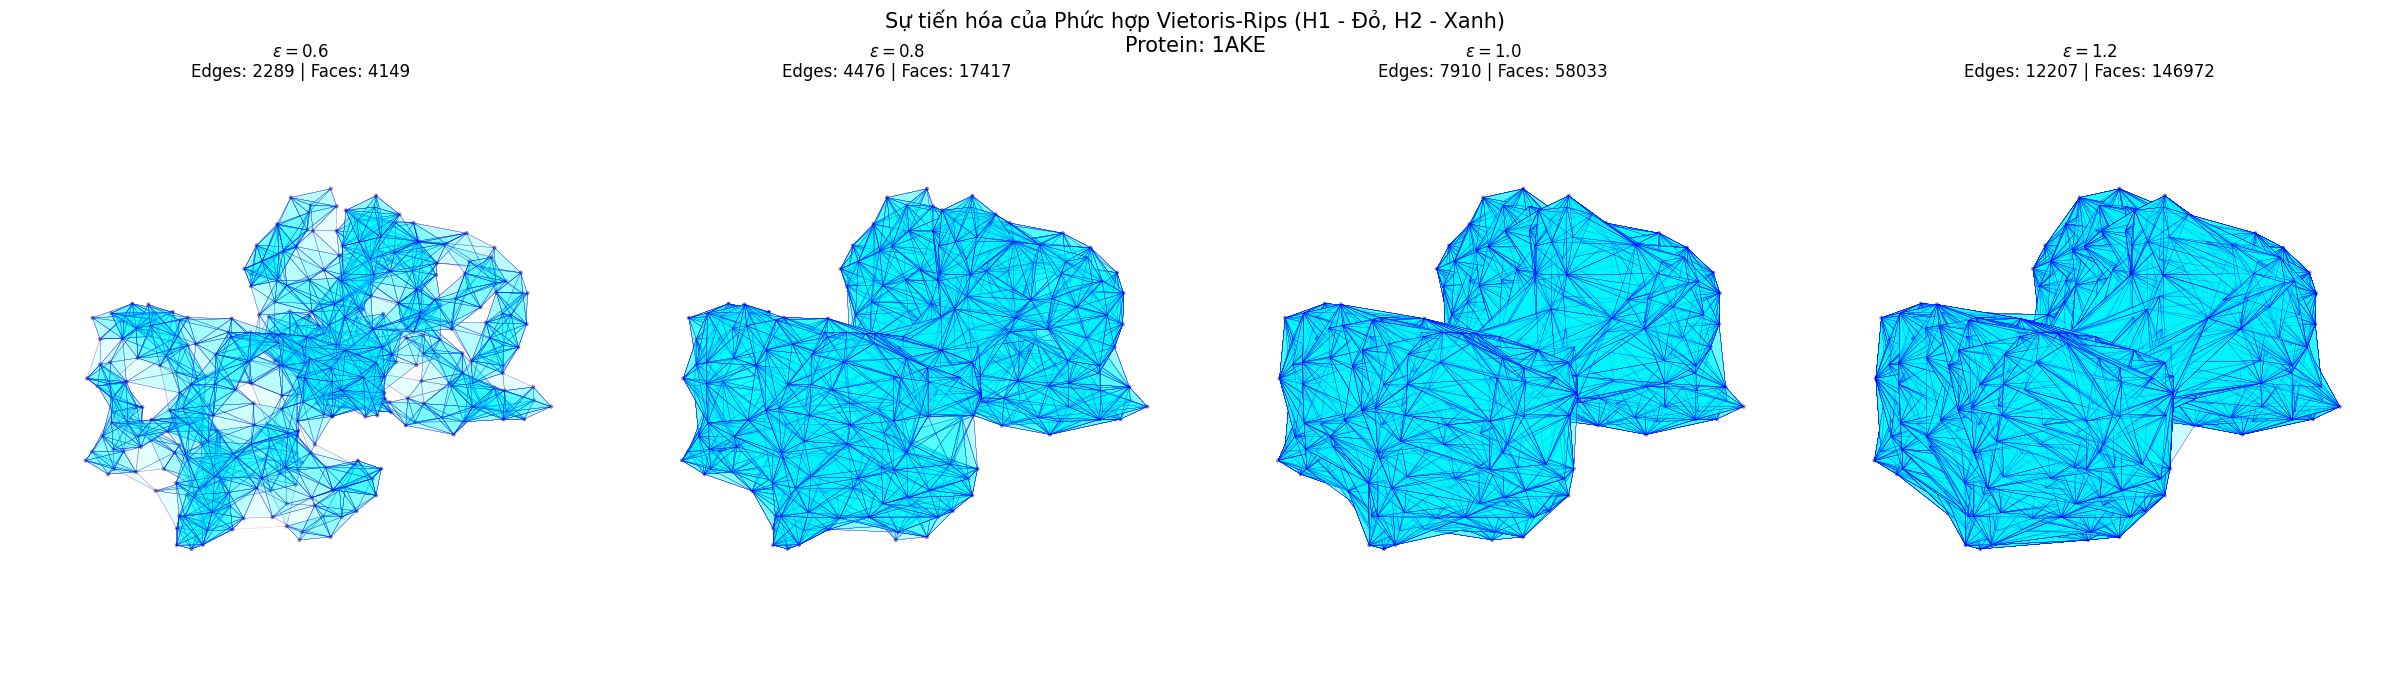

--- Đang phân tích đa chiều cho Protein 2RHE ---
  [+] Epsilon 0.60: 118 cạnh, 5 mặt tam giác.
  [+] Epsilon 0.80: 300 cạnh, 209 mặt tam giác.
  [+] Epsilon 1.00: 534 cạnh, 836 mặt tam giác.
  [+] Epsilon 1.20: 773 cạnh, 1898 mặt tam giác.


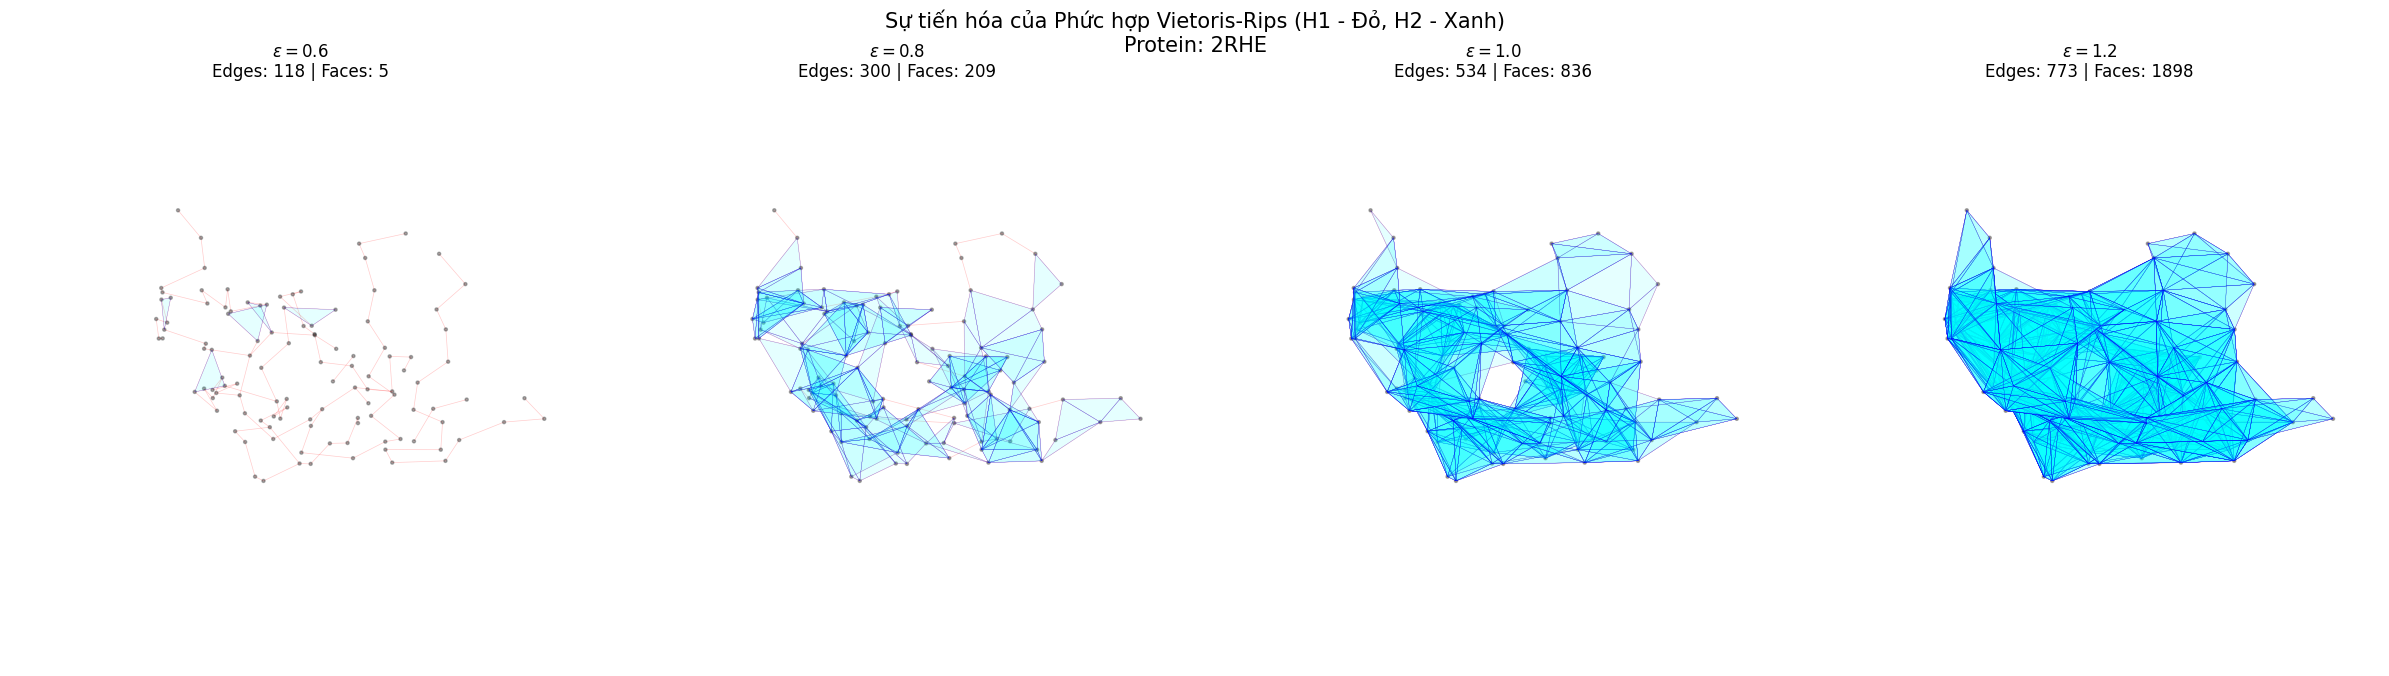

--- Đang phân tích đa chiều cho Protein 1GCN ---
  [+] Epsilon 0.60: 4 cạnh, 0 mặt tam giác.
  [+] Epsilon 0.80: 10 cạnh, 0 mặt tam giác.
  [+] Epsilon 1.00: 29 cạnh, 6 mặt tam giác.
  [+] Epsilon 1.20: 67 cạnh, 44 mặt tam giác.


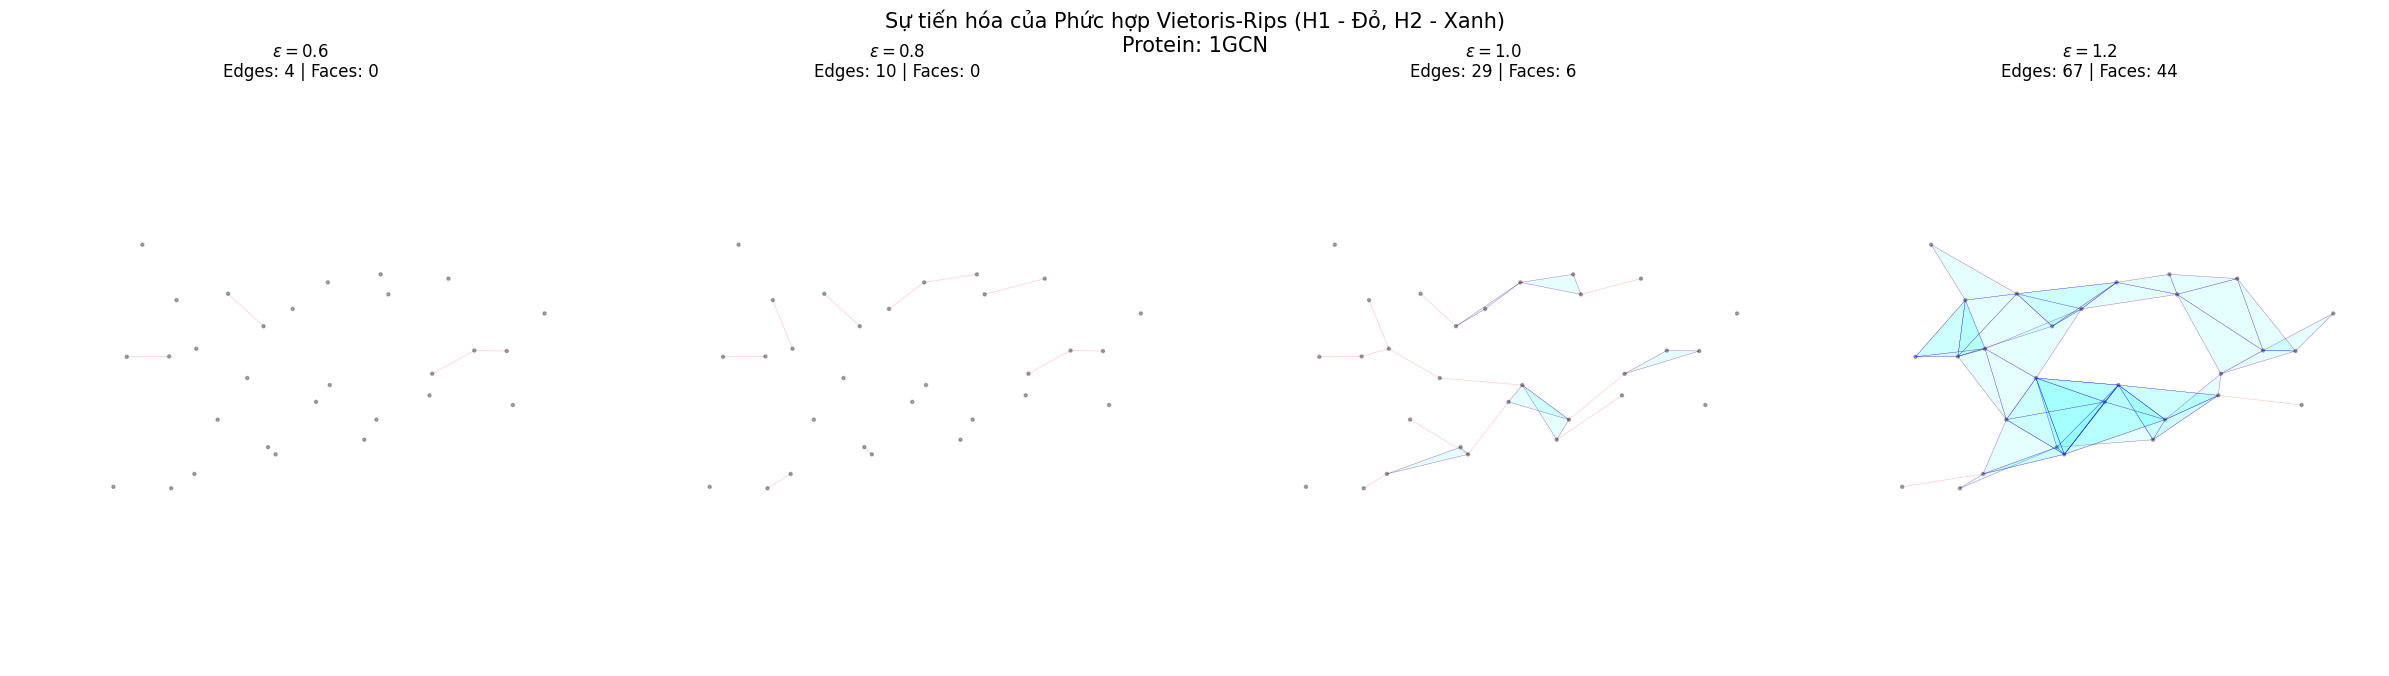

--- Đang phân tích đa chiều cho Protein 1CD8 ---
  [+] Epsilon 0.60: 132 cạnh, 1 mặt tam giác.
  [+] Epsilon 0.80: 291 cạnh, 207 mặt tam giác.
  [+] Epsilon 1.00: 502 cạnh, 718 mặt tam giác.
  [+] Epsilon 1.20: 736 cạnh, 1618 mặt tam giác.


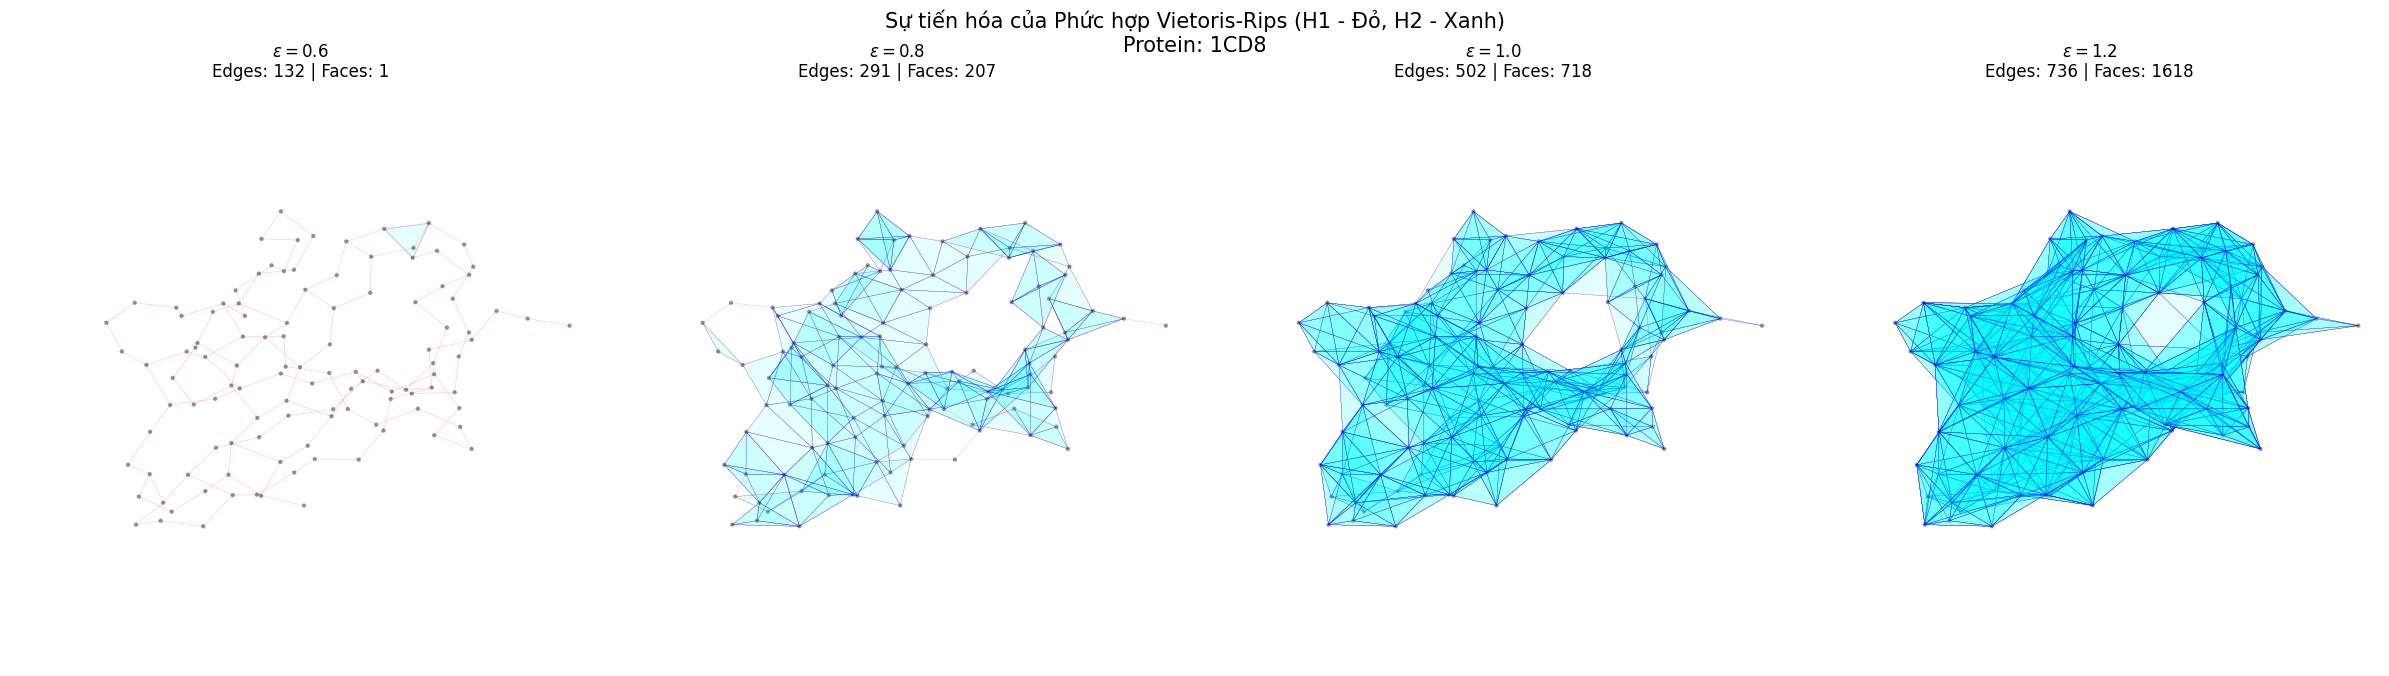

--- Đang phân tích đa chiều cho Protein 2PKA ---
  [+] Epsilon 0.60: 2457 cạnh, 4023 mặt tam giác.
  [+] Epsilon 0.80: 5403 cạnh, 22201 mặt tam giác.
  [+] Epsilon 1.00: 9792 cạnh, 79145 mặt tam giác.
  [+] Epsilon 1.20: 15598 cạnh, 215493 mặt tam giác.


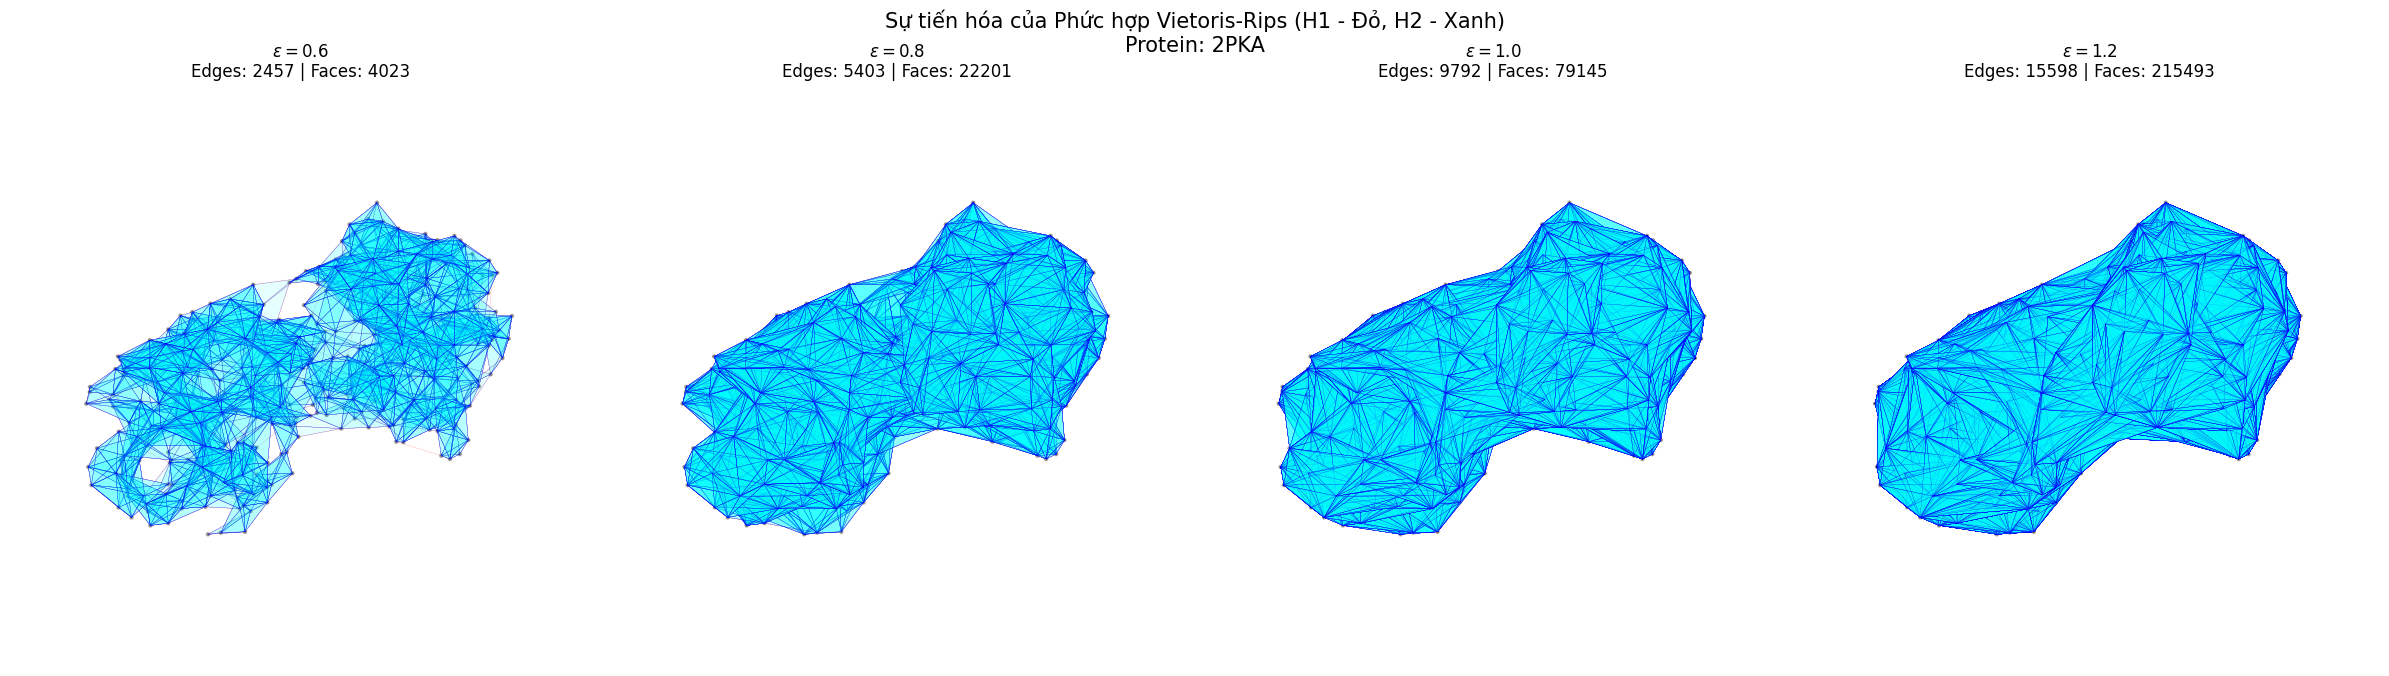

--- Đang phân tích đa chiều cho Protein 1QQT ---
  [+] Epsilon 0.60: 3562 cạnh, 7922 mặt tam giác.
  [+] Epsilon 0.80: 7349 cạnh, 36694 mặt tam giác.
  [+] Epsilon 1.00: 13078 cạnh, 125161 mặt tam giác.
  [+] Epsilon 1.20: 20345 cạnh, 322181 mặt tam giác.


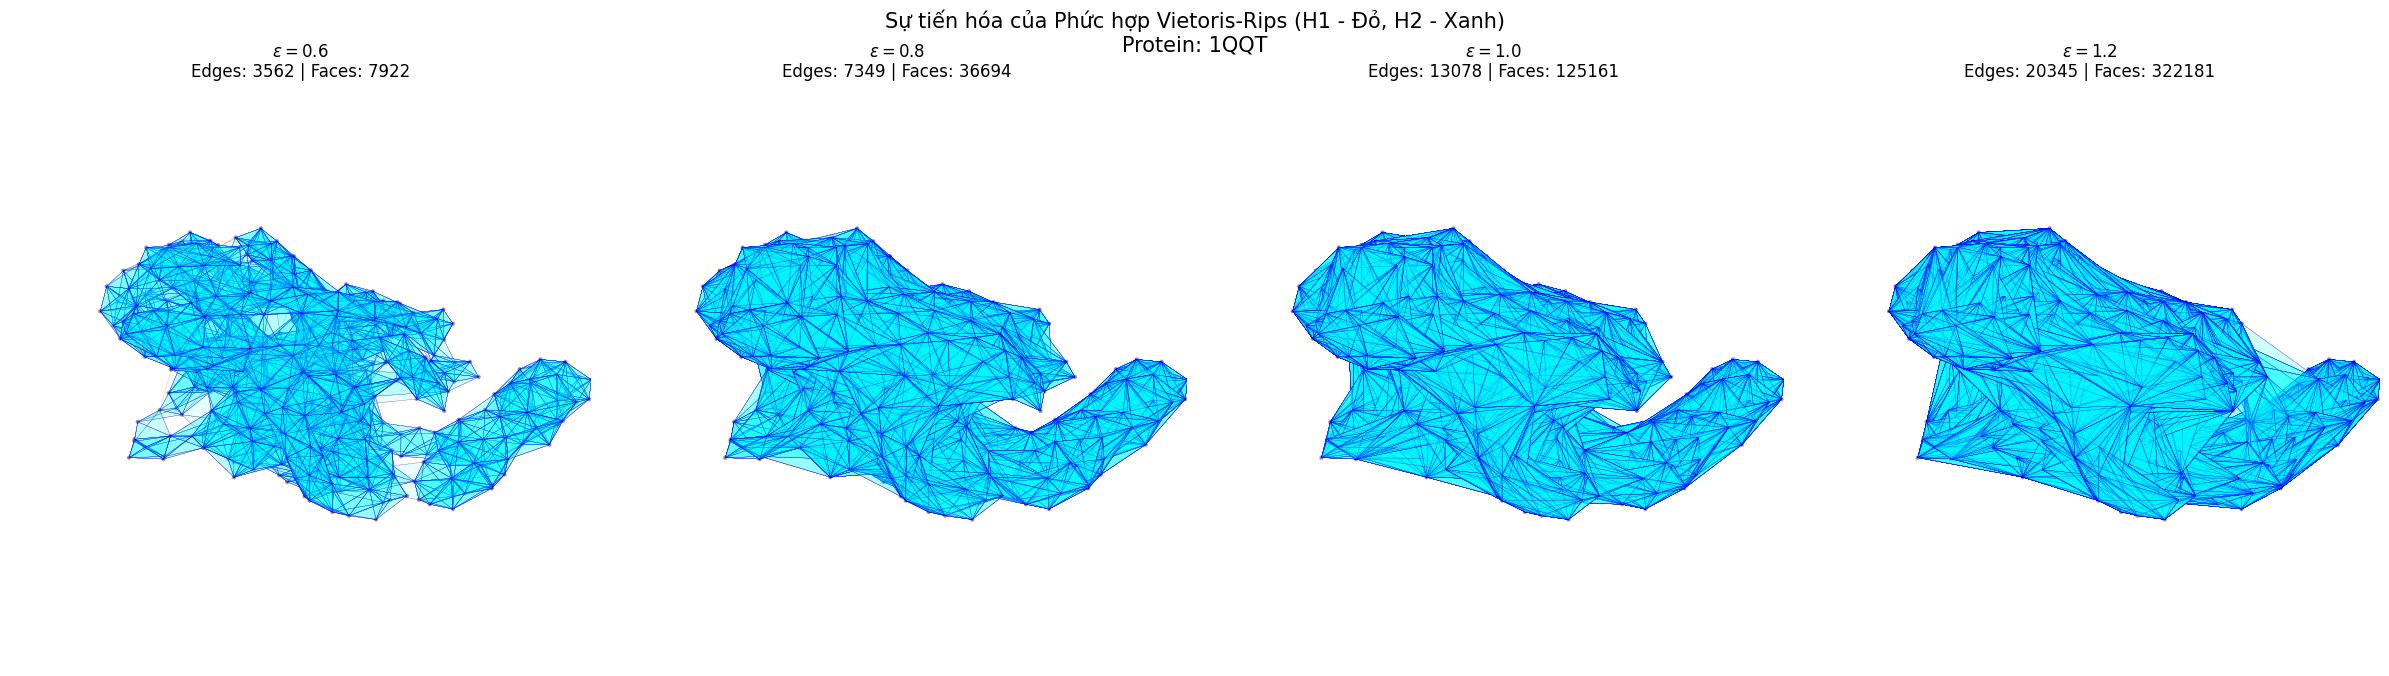

--- Đang phân tích đa chiều cho Protein 1TIM ---
  [+] Epsilon 0.60: 2390 cạnh, 3629 mặt tam giác.
  [+] Epsilon 0.80: 4864 cạnh, 16458 mặt tam giác.
  [+] Epsilon 1.00: 8972 cạnh, 60032 mặt tam giác.
  [+] Epsilon 1.20: 14468 cạnh, 167758 mặt tam giác.


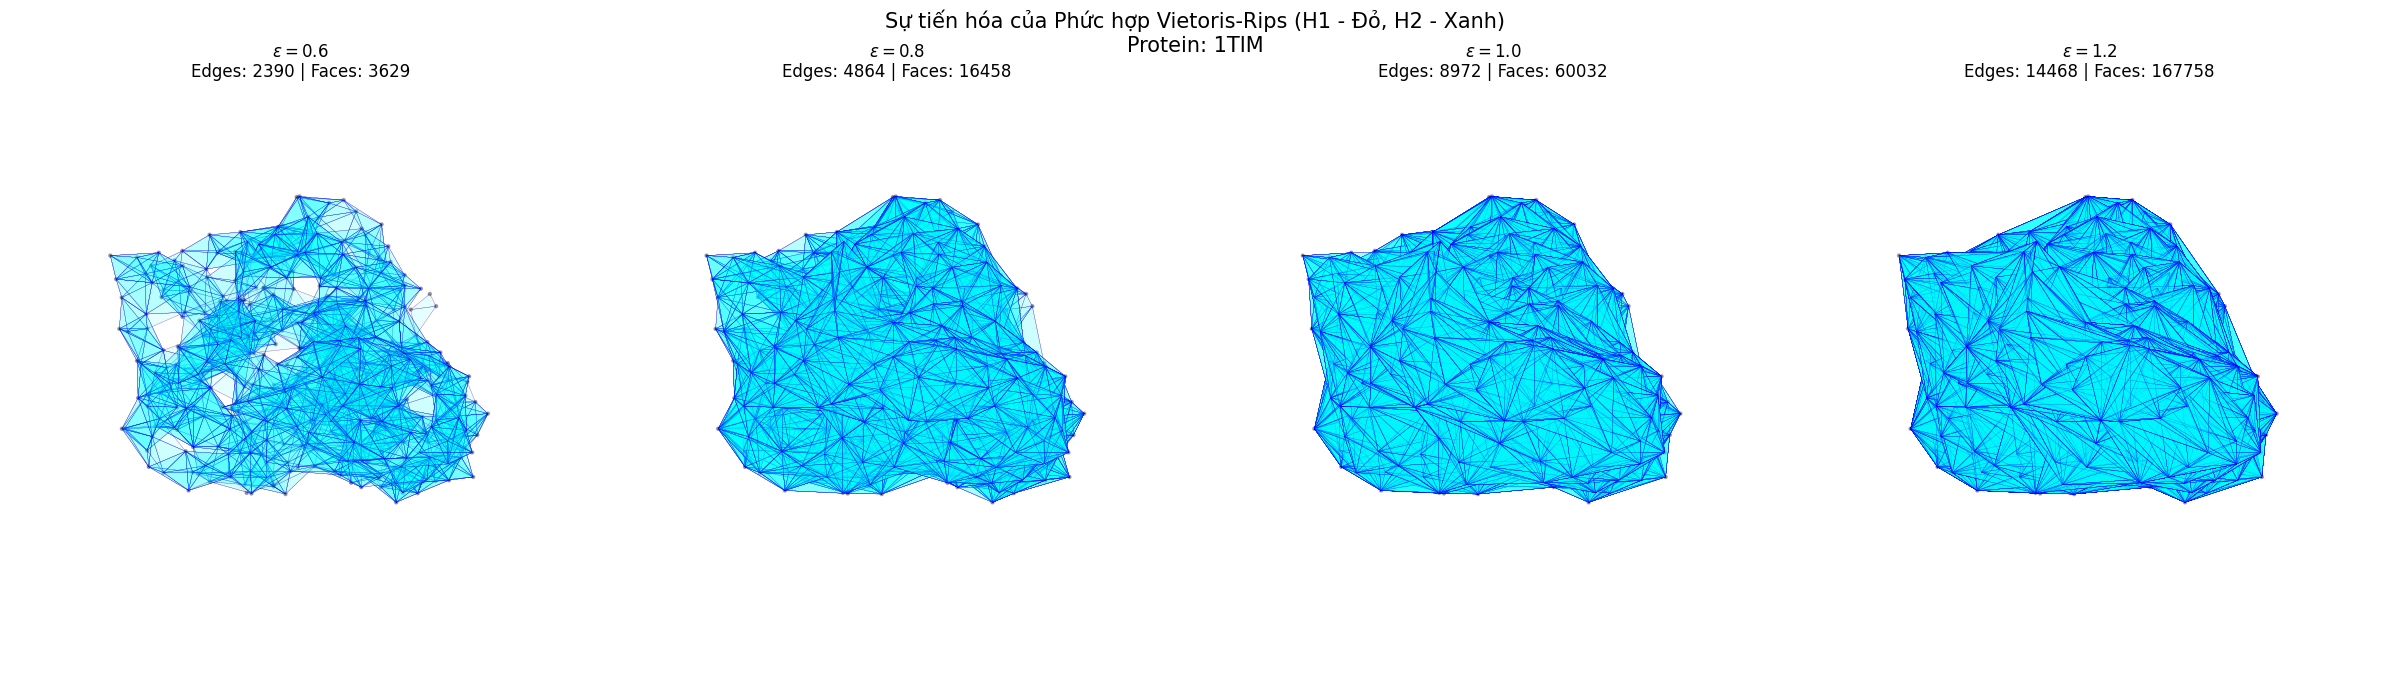

--- Đang phân tích đa chiều cho Protein 3TND ---
  [+] Epsilon 0.60: 7100 cạnh, 21603 mặt tam giác.
  [+] Epsilon 0.80: 15878 cạnh, 119849 mặt tam giác.
  [+] Epsilon 1.00: 28213 cạnh, 409432 mặt tam giác.


In [ ]:
my_eps_list = [0.6, 0.8, 1.0, 1.2]
for i in list_records:
  record = next(item for item in dataset if item["pdb_id"].lower() == i)
  points = record["point_cloud"]
  plot_multidim_filtration(points, my_eps_list)